In [1]:
import pandas as pd

# ROOT
root_path = "C:/Users/jackm/Documents/GitHub/ms-capstone-TTS-natlang-styleprompts"

# ParaSpeechCaps

In [9]:
from datasets import load_dataset
import pandas as pd

# Load the entire dataset
# dataset = load_dataset("ajd12342/paraspeechcaps")

# Load specific splits of the dataset
# train_scaled = load_dataset("ajd12342/paraspeechcaps", split="train_scaled") #Only has EMilia files
train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

dfs = [
    # train_scaled.to_pandas(),
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
df = pd.concat(dfs, ignore_index=True)

c:\Users\jackm\miniconda3\envs\capstone-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df.head()

,source,relative_audio_path,text_description,transcription,intrinsic_tags,situational_tags,basic_tags,all_tags,speakerid,name,duration,gender,accent,pitch,speaking_rate,noise,utterance_pitch_mean,snr,phonemes,tag_of_interest
0,voxceleb,voxceleb1/dev/wav/id11193/CbXwBsHMlbA/00001_vo...,[ A male speaker with an American accent deliv...,I did that from my heart. So that if they do ...,"[american, authoritative, flowing, raspy]",None,"[environment balanced in clarity, fast speed, ...","[american, authoritative, environment balanced...",id11193,Tupac Shakur,4.880063,male,american,medium-pitched,fast speed,environment balanced in clarity,146.627151,43.092300,aɪ dɪd ðæt fɹʌm maɪ hɑɹt. soʊ ðæt ɪf ðeɪ du t...,None
1,voxceleb,voxceleb2/dev/aac/id00708/s_qY2Q1gjaw/00415_vo...,"[ A deep-voiced man delivers authoritative, cr...","You know, people always refer to it as duct t...","[authoritative, american, crisp, deep, flowing]",None,"[environment balanced in clarity, low-pitched,...","[american, authoritative, crisp, deep, environ...",id00708,Antonin Scalia,7.800000,male,american,low-pitched,measured speed,environment balanced in clarity,102.925285,43.679882,"ju noʊ, pipʌl ɔlweɪz ɹʌfɜ˞ tu ɪt æz dʌkt teɪp...",None
2,voxceleb,voxceleb2/dev/aac/id05211/Qpv7DIHWDBA/00073_vo...,[ A female speaker with a medium-pitched voice...,lisa plays this like live floor tom um which ...,[australian],None,"[female, medium-pitched, noisy environment, sl...","[australian, female, medium-pitched, noisy env...",id05211,Lisa Origliasso,7.700000,female,australian,medium-pitched,slow speed,noisy environment,171.683182,28.372160,lisʌ pleɪz ðɪs laɪk laɪv flɔɹ tɑm ʌm wɪtʃ dʒʌ...,None
3,voxceleb,voxceleb2/test/aac/id05055/cZZMU1w_HO4/00349_v...,"[ A male speaker with a deep, low-pitched Amer...",And my coaches and teammates are going to hel...,"[deep, american]",None,"[fast speed, low-pitched, male, very noisy env...","[american, deep, fast speed, low-pitched, male...",id05055,LeBron James,7.900000,male,american,low-pitched,fast speed,very noisy environment,144.090042,21.178427,ʌnd maɪ koʊtʃɪz ʌnd timmeɪts ɑɹ ɡoʊɪŋ tu hɛlp...,None
4,voxceleb,voxceleb2/dev/aac/id03757/BP4bXjDuMFE/00044_vo...,[ A male speaker's voice is nasal and sing-son...,other people had had around me growing up in ...,"[nasal, singsong, american]",None,"[male, measured speed, medium-pitched, very no...","[american, male, measured speed, medium-pitche...",id03757,James Franco,4.700000,male,american,medium-pitched,measured speed,very noisy environment,109.919975,3.625704,ʌðɜ˞ pipʌl hæd hæd ɜ˞aʊnd mi ɡɹoʊɪŋ ʌp ɪn pæl...,None


In [10]:
# Duration in hours
total_hours = df["duration"].sum() / 3600
print(total_hours)

23.082813877314813


In [8]:
dur_by_source = df.groupby('source')['duration'].sum().reset_index()
dur_by_source["duration_hrs"] = dur_by_source['duration'] / 3600

dur_by_source

,source,duration,duration_hrs
0,ears,218409.000000,60.669167
1,expresso,109197.553312,30.332654
2,voxceleb,904715.809875,251.309947


In [11]:
df[df["source"]== "voxceleb"]

pd.set_option('display.max_colwidth', None)
df["text_description"]

0         [ A male speaker with an American accent delivers authoritative and flowing speech at a fast speed. His voice is raspy and medium-pitched, recorded in an environment that provides good balance in clarity.]
1                          [ A deep-voiced man delivers authoritative, crisp speech with a low pitch, recorded in an environment balanced in clarity. His measured speed and flowing rhythm convey an American accent.]
2                                                                          [ A female speaker with a medium-pitched voice delivers her speech in a slow manner against the backdrop of a noisy Australian environment.]
3                                                                                            [ A male speaker with a deep, low-pitched American accent delivers his speech at a fast pace in a very noisy environment.]
4                                                                            [ A male speaker's voice is nasal and sing-song in tone, sp

In [ ]:
# visualize tag distribution

import pandas as pd
import numpy as np

def is_populated(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    if isinstance(x, str):
        return x != 'None' and x.strip() != ''
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x) > 0
    return True  # fallback for other types

df['has_intrinsic'] = df['intrinsic_tags'].apply(is_populated)
df['has_situational'] = df['situational_tags'].apply(is_populated)

def categorize(row):
    if row['has_intrinsic'] and row['has_situational']:
        return 'both'
    elif row['has_intrinsic']:
        return 'intrinsic_only'
    elif row['has_situational']:
        return 'situational_only'
    else:
        return 'neither'

df['tag_category'] = df.apply(categorize, axis=1)

counts = (
    df.groupby(['source', 'tag_category'])
      .size()
      .unstack(fill_value=0)
)

import matplotlib.pyplot as plt

counts.plot(kind='bar')

plt.title('Tag Presence by Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()

plt.show()

### Preprocess Expresso

This should already be handled in the get_data.py script, but I repeated it here to help me during development.

In [5]:
import subprocess

expresso_root = r"../data/raw/paraspeechcaps/audio/expresso"

def execute(cmd, cwd=None):
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, cwd=cwd)
    
    for line in process.stdout:
        print(line, end="")
    
    # wait for process to finish and grab stderr
    _, stderr = process.communicate()
    if stderr:
        print("STDERR:", stderr)
    if process.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {process.returncode}: {cmd}")



In [ ]:
execute(["python", "../expresso_vad_multi.py", expresso_root])

Found 339 file(s), processing with 8 workers...
  [1/339] ex01-ex02_default_007.wav -> 0 segment(s)
  [2/339] ex01-ex02_default_002.wav -> 11 segment(s)
  [3/339] ex01-ex02_default_001.wav -> 15 segment(s)
  [4/339] ex01-ex02_default_003.wav -> 21 segment(s)
  [5/339] ex01-ex02_default_010.wav -> 35 segment(s)
  [6/339] ex01-ex02_default_004.wav -> 24 segment(s)
  [7/339] ex01-ex02_default_005.wav -> 26 segment(s)
  [8/339] ex01-ex02_default_012.wav -> 18 segment(s)
  [9/339] ex01-ex02_fast_001.wav -> 23 segment(s)
  [10/339] ex01-ex02_fast_002.wav -> 20 segment(s)
  [11/339] ex01-ex02_default_006.wav -> 38 segment(s)
  [12/339] ex01-ex02_default_011.wav -> 39 segment(s)
  [13/339] ex01-ex02_default_009.wav -> 87 segment(s)
  [14/339] ex01-ex02_enunciated_001.wav -> 90 segment(s)
  [15/339] ex01-ex02_fast_005.wav -> 30 segment(s)
  [16/339] ex01-ex02_fast_004.wav -> 55 segment(s)
  [17/339] ex01-ex02_fast_003.wav -> 77 segment(s)
  [18/339] ex01-ex02_fast_006.wav -> 28 segment(s)
  [19

In [ ]:
# loudness normalization
expresso_root = r"../data/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented"
execute(["python", "../normalize.py"])

In [19]:
result = subprocess.run(
    [r"C:\\Program Files\\Git\\bin\\bash.exe", "-c", f'find -L "{expresso_root_bash}" -type f -name "*.wav" | head -5'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

/d/JackCapstoneSpeechData/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented/ex01-ex02/default/ex01-ex02_default_001_channel1_segment_130.75_141.9.wav
/d/JackCapstoneSpeechData/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented/ex01-ex02/default/ex01-ex02_default_001_channel1_segment_167.15_198.24.wav
/d/JackCapstoneSpeechData/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented/ex01-ex02/default/ex01-ex02_default_001_channel1_segment_23.88_28.14.wav
/d/JackCapstoneSpeechData/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented/ex01-ex02/default/ex01-ex02_default_001_channel1_segment_55.12_61.83.wav
/d/JackCapstoneSpeechData/raw/paraspeechcaps/audio/expresso/audio_48khz/conversational_vad_segmented/ex01-ex02/default/ex01-ex02_default_001_channel1_segment_81.76_94.58.wav




In [ ]:
# clean duplicates and flatten annotation lists
import pandas as pd
from datasets import load_dataset
# Load specific splits of the dataset

train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

dfs = [
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
df = pd.concat(dfs, ignore_index=True)


# Only want conversational, already segmented files
df = df[df["source"] == "expresso"]


df = df[df["relative_audio_path"].str.contains("conversational_vad_segmented")]

# dedup: keep the row with the longer text_description list (throw out the basic tag style desc.)
dupes_mask = df.duplicated(subset="relative_audio_path", keep=False)
dupes = df[dupes_mask]
if not dupes.empty:
    print(f"Found {len(dupes)} duplicate rows across {dupes['relative_audio_path'].nunique()} paths -- keeping longest text_description per path")
    
    # longer list wins; ties go to the first occurrence
    df["_desc_len"] = df["text_description"].apply(lambda x: len(x) if hasattr(x, '__len__') and not isinstance(x, str) and len(x) > 0 else 0)
    df = (
        df.sort_values("_desc_len", ascending=False)
            .drop_duplicates(subset="relative_audio_path", keep="first")
            .drop(columns="_desc_len")
            .reset_index(drop=True)
    )
else:
    print("No duplicate paths found")

# flatten: reduce text_description from list to its first string (keep only the most rich style description)
df["text_description"] = df["text_description"].apply(
    lambda x: x[0] if hasattr(x, '__len__') and not isinstance(x, str) and len(x) > 0 else x
)

non_str = df[~df["text_description"].apply(lambda x: isinstance(x, str))]

if non_str.empty:
    print("All values are str")
else:
    print(f"{len(non_str)} non-string values found:\n")
    for _, row in non_str.iterrows():
        print(f"  path: {row['relative_audio_path']}")
        print(f"  type: {type(row['text_description'])}")
        print(f"  value: {row['text_description']}\n")

Found 118 duplicate rows across 58 paths -- keeping longest text_description per path
All values are str


In [2]:
# Check sample rate

import soundfile as sf
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import pandas as pd
from datasets import load_dataset
# Load specific splits of the dataset

train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

dfs = [
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
df = pd.concat(dfs, ignore_index=True)

# Only want conversational, already segmented files
df = df[df["source"] == "expresso"]
df = df[df["relative_audio_path"].str.contains("conversational_vad_segmented")]

df_audio_root = Path("../data_TEMP/paraspeechcaps/audio/expresso")

sr_counter = Counter()
missing = []

for rel_path in tqdm(df["relative_audio_path"].dropna().unique(), desc="Scanning SRs"):
    full_path = df_audio_root / rel_path
    if not full_path.exists():
        missing.append(rel_path)
        continue
    # sf.info is much faster than reading the whole file
    info = sf.info(str(full_path))
    sr_counter[info.samplerate] += 1

print(f"\nSample rate distribution:")
for sr, count in sorted(sr_counter.items()):
    print(f"  {sr:,} Hz : {count:,} files")

print(f"\nMin SR : {min(sr_counter):,} Hz")
print(f"Max SR : {max(sr_counter):,} Hz")

if missing:
    print(f"\nMissing files: {len(missing):,}")

Scanning SRs: 100%|██████████| 8868/8868 [00:54<00:00, 161.41it/s]


Sample rate distribution:
  48,000 Hz : 8,868 files

Min SR : 48,000 Hz
Max SR : 48,000 Hz


# StyleTalk

In [6]:
styletalk_root = f"../data/raw/styletalk"

In [ ]:
import pandas as pd
df_styletalk_eval_meta = pd.read_csv(
    f"{styletalk_root}/annotations/eval.csv",
    sep=",",            # delimiter
    encoding="utf-8",   # or "latin1"
    na_values=["NA", ""],
)

df_styletalk_eval_meta

In [ ]:
# Find total duration of StyleTalk: RESULTS = 7 hours

"""
Recursively sum the total duration of all WAV files in a directory.
Usage: python sum_wav_durations.py [directory]
"""

import sys
import wave
import os
from pathlib import Path
from tqdm import tqdm

# Sonnet 4.6: 

def get_wav_duration(filepath: Path) -> float:
    """Return duration of a WAV file in seconds, or None on error."""
    try:
        with wave.open(str(filepath), "rb") as f:
            frames = f.getnframes()
            rate = f.getframerate()
            return frames / rate
    except Exception as e:
        tqdm.write(f"[WARN] Could not read {filepath}: {e}")
        return None


def format_duration(seconds: float) -> str:
    """Format seconds into a human-readable string."""
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    parts = []
    if h:
        parts.append(f"{h}h")
    if m or h:
        parts.append(f"{m}m")
    parts.append(f"{s:.2f}s")
    return " ".join(parts)


def scan_directory(root: Path):
    total_seconds = 0.0
    file_count = 0
    error_count = 0

    wav_files = sorted(root.rglob("*.wav")) + sorted(root.rglob("*.WAV"))
    # Deduplicate (case-sensitive filesystems may return both)
    seen = set()
    unique_wavs = []
    for f in wav_files:
        if f not in seen:
            seen.add(f)
            unique_wavs.append(f)

    if not unique_wavs:
        print(f"No WAV files found under: {root}")
        return

    print(f"Scanning: {root}\n")

    with tqdm(unique_wavs, unit="file", dynamic_ncols=True) as pbar:
        for filepath in pbar:
            rel = filepath.relative_to(root)
            pbar.set_postfix_str(str(rel), refresh=True)

            duration = get_wav_duration(filepath)
            if duration is not None:
                total_seconds += duration
                file_count += 1
            else:
                error_count += 1

    print(f"\n{'─' * 60}")
    print(f"  Files found   : {file_count + error_count}")
    print(f"  Files read    : {file_count}")
    if error_count:
        print(f"  Errors        : {error_count}")
    print(f"  Total duration: {format_duration(total_seconds)}  ({total_seconds:.2f}s)")



directory = Path(f"{styletalk_root}/audio")

if not directory.exists():
    print(f"Error: directory not found: {directory}")
    sys.exit(1)
if not directory.is_dir():
    print(f"Error: not a directory: {directory}")
    sys.exit(1)

scan_directory(directory)

Scanning: C:\Users\jackm\Documents\GitHub\ms-capstone-TTS-natlang-styleprompts\src\data\raw\styletalk\audio



100%|██████████| 5392/5392 [00:35<00:00, 153.77file/s, work_98\r_2.wav]         



────────────────────────────────────────────────────────────
  Files found   : 5392
  Files read    : 5392
  Total duration: 7h 7m 54.19s  (25674.19s)


In [5]:
# Check sample rate
import pandas as pd

import soundfile as sf
from pathlib import Path
from tqdm import tqdm
from collections import Counter

st_df = pd.read_parquet("../data/processed/merged_PSC_StyleTalk_CLEANED.parquet")
st_df = st_df[st_df["source"] == "styletalk"]
st_df = st_df[st_df["record_type"] != "text_only"]  # no audio to check

st_audio_root = Path("../data_TEMP/styletalk/audio")

sr_counter = Counter()
missing = []

for rel_path in tqdm(st_df["relative_audio_path"].dropna().unique(), desc="Scanning SRs"):
    full_path = st_audio_root / rel_path
    if not full_path.exists():
        missing.append(rel_path)
        continue
    # sf.info is much faster than reading the whole file
    info = sf.info(str(full_path))
    sr_counter[info.samplerate] += 1

print(f"\nSample rate distribution:")
for sr, count in sorted(sr_counter.items()):
    print(f"  {sr:,} Hz : {count:,} files")

print(f"\nMin SR : {min(sr_counter):,} Hz")
print(f"Max SR : {max(sr_counter):,} Hz")

if missing:
    print(f"\nMissing files: {len(missing):,}")

Scanning SRs: 100%|██████████| 5392/5392 [00:31<00:00, 170.23it/s]


Sample rate distribution:
  16,000 Hz : 5,392 files

Min SR : 16,000 Hz
Max SR : 16,000 Hz


# Final HDF5 Dataset

In [1]:
import pandas as pd

# Load
# df = pd.read_parquet("../data/processed/merged_metadata.parquet")
df = pd.read_parquet("../data_TEMP/merged_metadata_500.parquet")

# Overview
print(f"Shape: {df.shape}")
print(f"\nhdf5_idx breakdown:")
print(f"  Audio rows   (>= 0) : {(df['hdf5_idx'] >= 0).sum():,}")
print(f"  Text-only   (== -1) : {(df['hdf5_idx'] == -1).sum():,}")
print(f"  Errors      (== -2) : {(df['hdf5_idx'] == -2).sum():,}")

display(df.dtypes.to_frame("dtype"))

# Sample: audio rows
print("\n--- 3 audio rows ---")
display(df[df["hdf5_idx"] >= 0].sample(3).T)

# Sample: text-only rows
text_only = df[df["hdf5_idx"] == -1]
if len(text_only):
    print("\n--- 3 text-only rows ---")
    display(text_only.sample(min(3, len(text_only))).T)
else:
    print("No text-only rows found -- hdf5_idx == -1 may not exist yet, or record_type values differ.")
    print("Unique record_type values:", df["record_type"].unique())

# Flag any unexpected errors
errors = df[df["hdf5_idx"] == -2]
if len(errors):
    print(f"\n--- {len(errors)} ERROR rows (audio expected but missing) ---")
    display(errors[["source", "relative_audio_path", "record_type"]].head(10))
else:
    print("\nNo error rows -- all audio files accounted for.")

Shape: (500, 27)

hdf5_idx breakdown:
  Audio rows   (>= 0) : 350
  Text-only   (== -1) : 150
  Errors      (== -2) : 0


,dtype
source,str
relative_audio_path,str
text_description,str
transcription,str
intrinsic_tags,object
situational_tags,object
basic_tags,object
all_tags,object
speakerid,str
name,str



--- 3 audio rows ---


,389,58,212
source,styletalk,expresso,expresso
relative_audio_path,work_430/r_2.wav,audio_48khz/conversational_vad_segmented/ex03-...,audio_48khz/conversational_vad_segmented/ex04-...
text_description,"The speaker speaks in a friendly tone, at a no...","A male speaker delivers a discernible, author...",A male speaker with an American accent singso...
transcription,"With this energy? Absolutely! And hopefully,...",it's like it's like imagine if you like sweat...,Right. Okay. We're going to eat like a giant ...
intrinsic_tags,None,"[authoritative, flowing, nasal, american, sing...","[authoritative, flowing, american, nasal, sing..."
situational_tags,None,[disgusted],[fast]
basic_tags,"[friendly, normal, normal]","[environment balanced in clarity, high-pitched...","[high-pitched, male, measured speed, slightly ..."
all_tags,"[friendly, normal, normal]","[american, authoritative, disgusted, environme...","[american, authoritative, fast, flowing, high-..."
speakerid,A,ex03,ex03
name,NaN,ex03,ex03



--- 3 text-only rows ---


,480,396,295
source,styletalk,styletalk,styletalk
relative_audio_path,music_533/c_2.wav_turn_0,school_179/c_0.wav_turn_1,sport_303/c_0.wav_turn_0
text_description,NaN,NaN,NaN
transcription,"I just went to that new record store, and they...",That's fantastic! We should totally celebrate ...,"I can't believe we won the game, this is absol..."
intrinsic_tags,None,None,None
situational_tags,None,None,None
basic_tags,None,None,None
all_tags,None,None,None
speakerid,A,B,A
name,NaN,NaN,NaN



No error rows -- all audio files accounted for.


In [ ]:
display(df[df["source"] == "styletalk"])

In [3]:
import h5py
import numpy as np

# with h5py.File("../data/processed/merged_audio.h5", "r") as hf:
with h5py.File("../data_TEMP/merged_audio_500.h5", "r") as hf:

    # top-level attrs (paths, totals written at build time)
    print("=== File attrs ===")
    for k, v in hf.attrs.items():
        print(f"  {k}: {v}")

    # pick a few samples to inspect
    keys = list(hf["audio"].keys())
    print(f"\nTotal datasets: {len(keys)}")

    for key in keys[:3]:
        ds = hf["audio"][key]
        print(f"\n--- audio/{key} ---")
        print(f"  shape      : {ds.shape}  (samples,)")
        print(f"  dtype      : {ds.dtype}")
        print(f"  duration   : {ds.attrs['duration_sec']:.2f}s  @ {ds.attrs['sample_rate']}Hz")
        print(f"  source row : df row {ds.attrs['df_row']}")
        print("  attrs:")
        for k, v in ds.attrs.items():
            print(f"    {k}: {v}")

        # sanity check the waveform values -- if something went wrong
        # during loading (clipping, silence, etc.) this will show it
        waveform = ds[()]
        print(f"  waveform   : min={waveform.min():.4f}  max={waveform.max():.4f}  mean={waveform.mean():.4f}")

=== File attrs ===
  audio_root_PSC: ..\data_TEMP\paraspeechcaps\audio\expresso
  audio_root_ST: ..\data_TEMP\styletalk\audio
  resample_rate: 16000
  source_df: ..\data_TEMP\merged_PSC_StyleTalk_CLEANED.parquet
  total_audio_samples: 350
  total_text_only: 150

Total datasets: 350

--- audio/000000 ---
  shape      : (63360,)  (samples,)
  dtype      : float32
  duration   : 3.96s  @ 16000Hz
  source row : df row 98
  attrs:
    accent: american
    conv_id: ex01-ex02_fast_003
    df_row: 98
    duration_sec: 3.96
    gender: male
    name: ex01
    noise: very clean environment
    original_path: audio_48khz/conversational_vad_segmented/ex01-ex02/fast/ex01-ex02_fast_003_channel1_segment_139.68_143.64.wav
    pitch: high-pitched
    prev_filename: 
    record_type: audio
    relative_audio_path: audio_48khz/conversational_vad_segmented/ex01-ex02/fast/ex01-ex02_fast_003_channel1_segment_139.68_143.64.wav
    sample_rate: 16000
    snr: 76.08734893798828
    source: expresso
    speaker

Duration percentiles (seconds):
  p 50: 5.26s
  p 75: 7.92s
  p 90: 14.65s
  p 95: 21.37s
  p 99: 41.23s
  p100: 156.28s

Mean  : 7.60s
Median: 5.26s
Total clips: 14,260

% of clips truncated at each max_len_sec:
    5s: 54.1% truncated  (7,710 clips)
    8s: 24.6% truncated  (3,511 clips)
   10s: 17.7% truncated  (2,522 clips)
   15s: 9.6% truncated  (1,366 clips)
   20s: 5.7% truncated  (812 clips)


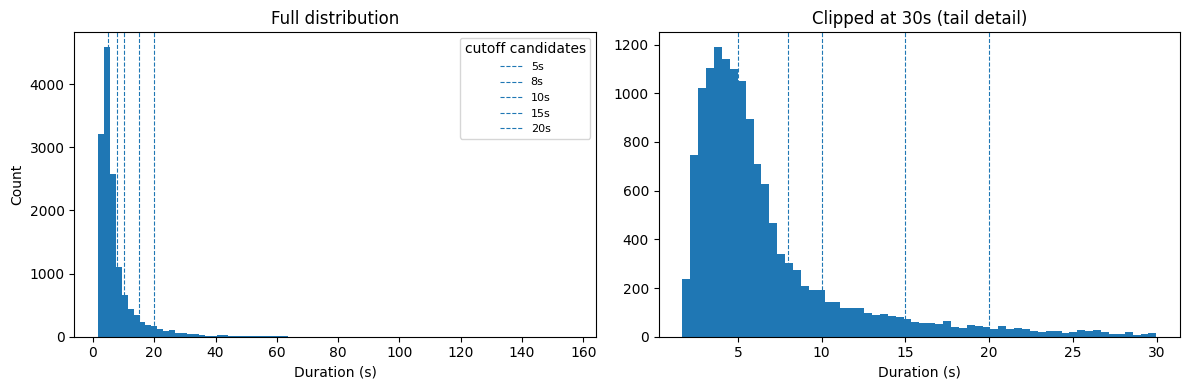

In [5]:
# Duration distribution of audio clips (to inform max_len_sec for training)
import numpy as np
import matplotlib.pyplot as plt

META_PATH = "../data_TEMP/merged_metadata_full.parquet"  # update for full dataset

audio_df = pd.read_parquet(META_PATH)
audio_df = audio_df[audio_df["hdf5_idx"] >= 0]
durations = audio_df["duration"].values

pcts = [50, 75, 90, 95, 99, 100]
vals = np.percentile(durations, pcts)

print("Duration percentiles (seconds):")
for p, v in zip(pcts, vals):
    print(f"  p{p:>3}: {v:.2f}s")

print(f"\nMean  : {durations.mean():.2f}s")
print(f"Median: {np.median(durations):.2f}s")
print(f"Total clips: {len(durations):,}")

cutoffs = [5, 8, 10, 15, 20]
print("\n% of clips truncated at each max_len_sec:")
for c in cutoffs:
    truncated = (durations > c).mean() * 100
    print(f"  {c:>3}s: {truncated:.1f}% truncated  ({(durations > c).sum():,} clips)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(durations, bins=80, edgecolor="none")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Full distribution")
for c in cutoffs:
    axes[0].axvline(c, linestyle="--", linewidth=0.8, label=f"{c}s")
axes[0].legend(title="cutoff candidates", fontsize=8)

axes[1].hist(durations[durations <= 30], bins=60, edgecolor="none")
axes[1].set_xlabel("Duration (s)")
axes[1].set_title("Clipped at 30s (tail detail)")
for c in cutoffs:
    axes[1].axvline(c, linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()


In [ ]:
# duplicate check in raw dataset
import pandas as pd
from datasets import load_dataset

train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base")
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

df = pd.concat(
    [train_base.to_pandas(), holdout.to_pandas(), dev.to_pandas(), test.to_pandas()],
    ignore_index=True,
)

df = df[df["source"] == "expresso"]
meta_raw = df[df["relative_audio_path"].str.contains("conversational_vad_segmented")]
meta_df = meta_raw[meta_raw["source"] == "expresso"]

dupes = meta_df[meta_df.duplicated(subset="relative_audio_path", keep=False)]

# sort so matching paths appear together
dupes = dupes.sort_values("relative_audio_path")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # don't truncate if there are many dupes

if dupes.empty:
    print("No duplicate paths found")
else:
    print(f"{len(dupes)} rows, {dupes['relative_audio_path'].nunique()} unique paths affected")
    display(dupes)

In [4]:
# dupe check in merged
import pandas as pd

META_PATH = "../data_TEMP/merged_PSC_StyleTalk_CLEANED.parquet"
meta_raw = pd.read_parquet(META_PATH)

dupes = meta_raw[meta_raw.duplicated(subset="relative_audio_path", keep=False)]

if dupes.empty:
    print("No duplicate paths found")
else:
    print(f"{len(dupes)} rows share a duplicate path ({dupes['relative_audio_path'].nunique()} unique paths affected)\n")
    for path, group in dupes.groupby("relative_audio_path"):
        print(f"  {path}")
        print(group[[ "turn_index", "prev_filename"]].to_string(index=True))
        print()

No duplicate paths found


In [3]:
# checking nan GT values
import pandas as pd

META_PATH = "../data_TEMP/merged_metadata_full.parquet"  # adjust path as needed

meta = pd.read_parquet(META_PATH)

problem_rows = meta[
    meta["text_description"].isna()
]

print(f"{len(problem_rows)} audio rows with missing text_description")
print(f"  by source:\n{problem_rows['source'].value_counts().to_string()}")
problem_rows[["relative_audio_path", "source", "conv_id", "turn_index", "record_type", "text_description"]].head(20)


8088 audio rows with missing text_description
  by source:
source
styletalk    8088


,relative_audio_path,source,conv_id,turn_index,record_type,text_description
8868,book_269/c_2.wav_turn_0,styletalk,book_269,0,text_only,NaN
8869,book_269/c_2.wav_turn_1,styletalk,book_269,1,text_only,NaN
8870,book_269/c_2.wav_turn_2,styletalk,book_269,2,text_only,NaN
8873,health_473/c_2.wav_turn_0,styletalk,health_473,0,text_only,NaN
8874,health_473/c_2.wav_turn_1,styletalk,health_473,1,text_only,NaN
8875,health_473/c_2.wav_turn_2,styletalk,health_473,2,text_only,NaN
8878,music_540/c_0.wav_turn_0,styletalk,music_540,0,text_only,NaN
8879,music_540/c_0.wav_turn_1,styletalk,music_540,1,text_only,NaN
8880,music_540/c_0.wav_turn_2,styletalk,music_540,2,text_only,NaN
8883,family_517/c_2.wav_turn_0,styletalk,family_517,0,text_only,NaN
